# Experimental Pose-Aware 2.5D Try-On Bridge

This notebook is an **experimental** bridge after the current strong 2D baseline.

It still uses:
- the trained segmentation model
- the reviewed render-safe 2D live bank
- MediaPipe landmarks

But it explores a pose-aware 2.5D warp only as a research-style engine experiment.
It is **not** the default runtime path because current single-view assets do not yet gain a reliable quality improvement from this warp.

Real 3D hairstyle assets come later.


In [16]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from app.core.asset_bank import asset_bank_summary, get_asset_by_id
from app.core.face_analyzer import analyze_face_image
from app.core.hair_segmentation import predict_hair_mask_image_from_face_roi
from app.core.recommender import recommend_hairstyles
from app.core.tryon_2d_engine import render_static_tryon_image
from app.core.tryon_25d_engine import render_pose_aware_tryon_image, estimate_pose_warp_parameters
from app.core.tryon_3d_metadata import estimate_head_anchor_frame
from app.models.schemas import FaceAttributes, RecommendationPreferences


In [17]:
INPUT_IMAGE_PATH = PROJECT_ROOT / 'backend' / 'outputs' / 'uploads' / '3c051efb9ea4468ab2c46dd7123dff11.jpg'
OUTPUT_DIR = PROJECT_ROOT / 'backend' / 'outputs' / 'evaluations' / 'lightweight_3d_tryon'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_GENDER = 'male'
TOP_K = 3

print('Input image:', INPUT_IMAGE_PATH)
print('Output dir:', OUTPUT_DIR)
print('Asset bank summary:', asset_bank_summary())

Input image: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\uploads\3c051efb9ea4468ab2c46dd7123dff11.jpg
Output dir: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\evaluations\lightweight_3d_tryon
Asset bank summary: {'asset_count': 83, 'metadata_dir': 'D:\\Projects\\Personal Projects\\Hairstyle Recommender Live Tryon\\backend\\data\\processed\\celeba_full_hair_assets\\reviewed_render_safe\\kept_assets.jsonl'}


In [18]:
analysis = analyze_face_image(INPUT_IMAGE_PATH)
if not analysis.face_detected:
    raise RuntimeError('No face detected in input image.')

subject_hair_mask = predict_hair_mask_image_from_face_roi(Image.open(INPUT_IMAGE_PATH).convert('RGB'), analysis.face_bbox)
head_anchor = estimate_head_anchor_frame(analysis)

display(pd.DataFrame([head_anchor]))

,anchor_strategy,head_anchor,eye_center,temple_center,forehead_center,eye_distance_px,temple_span_px,face_height_px,roll_degrees,yaw_proxy,pitch_proxy,lighting_mode,status
0,mediapipe_temples_forehead,"{'x': 603.55, 'y': 250.01}","{'x': 602.67, 'y': 337.94}","{'x': 603.55, 'y': 362.88}","{'x': 603.16, 'y': 250.01}",105.38,234.97,285.15,0.72,-0.0024,-0.3457,estimated_from_input,lightweight_head_anchor


In [19]:
face_attributes = FaceAttributes.model_validate(analysis.face_attributes)
preferences = RecommendationPreferences(target_gender=TARGET_GENDER)
recommendation_response = recommend_hairstyles(face_attributes, preferences=preferences, top_k=TOP_K)
recommendations = recommendation_response.recommendations

rows = []
for item in recommendations:
    asset = get_asset_by_id(item.asset_id)
    pose = estimate_pose_warp_parameters(analysis, asset) if asset else None
    rows.append({
        'asset_id': item.asset_id,
        'score': round(item.score, 4),
        'style_family': item.normalized_attributes.style_family,
        'length': item.normalized_attributes.length,
        'curl': item.normalized_attributes.curl,
        'yaw_strength': None if pose is None else round(pose['yaw_strength'], 4),
        'pitch_strength': None if pose is None else round(pose['pitch_strength'], 4),
        'roll_degrees': None if pose is None else round(pose['roll_degrees'], 3),
        'depth_bias': None if pose is None else round(pose['depth_bias'], 3),
        'side_fall_bias': None if pose is None else round(pose['side_fall_bias'], 3),
        'reason': item.reason,
    })

recommendation_table = pd.DataFrame(rows)
display(recommendation_table)

,asset_id,score,style_family,length,curl,yaw_strength,pitch_strength,roll_degrees,depth_bias,side_fall_bias,reason
0,celeba_full_hair_000064,0.960,pompadour,medium,straight,-0.0043,-0.28,0.72,0.18,0.15,pompadour works well with balanced facial prop...
1,celeba_full_hair_000084,0.945,pompadour,medium,straight,-0.0043,-0.28,0.72,0.18,0.15,pompadour works well with balanced facial prop...
2,celeba_full_hair_000158,0.930,pompadour,medium,straight,-0.0043,-0.28,0.72,0.18,0.15,pompadour works well with balanced facial prop...


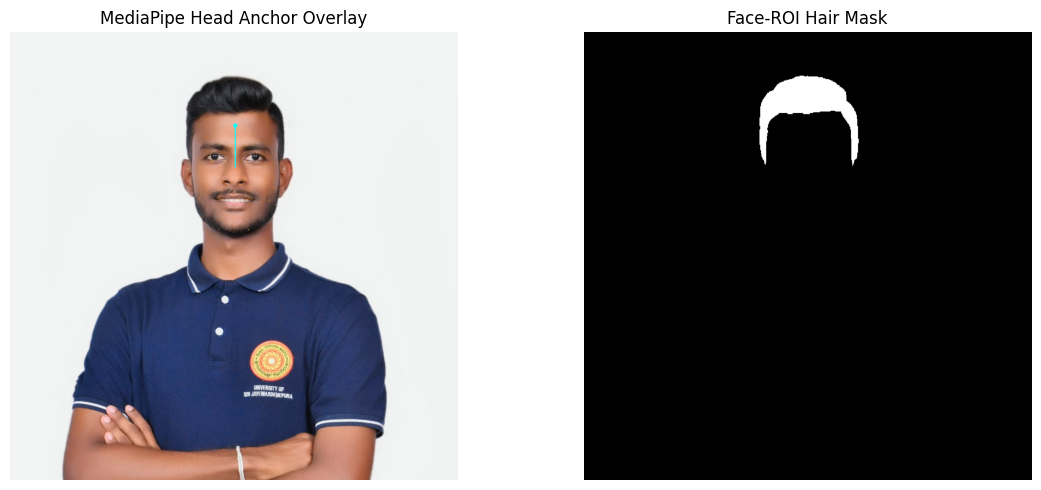

In [20]:
input_image = Image.open(INPUT_IMAGE_PATH).convert('RGB')
annotated = input_image.copy()
draw = ImageDraw.Draw(annotated)

for landmark in analysis.landmarks[::8]:
    x = landmark.x * analysis.image_width
    y = landmark.y * analysis.image_height
    draw.ellipse((x - 1, y - 1, x + 1, y + 1), fill=(255, 140, 0))

if head_anchor:
    anchor = head_anchor['head_anchor']
    draw.ellipse((anchor['x'] - 5, anchor['y'] - 5, anchor['x'] + 5, anchor['y'] + 5), fill=(0, 255, 255))
    temples = head_anchor['temple_center']
    forehead = head_anchor['forehead_center']
    draw.line((temples['x'], temples['y'], forehead['x'], forehead['y']), fill=(0, 255, 255), width=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(annotated)
axes[0].set_title('MediaPipe Head Anchor Overlay')
axes[0].axis('off')
axes[1].imshow(subject_hair_mask, cmap='gray')
axes[1].set_title('Face-ROI Hair Mask')
axes[1].axis('off')
plt.tight_layout()
plt.show()

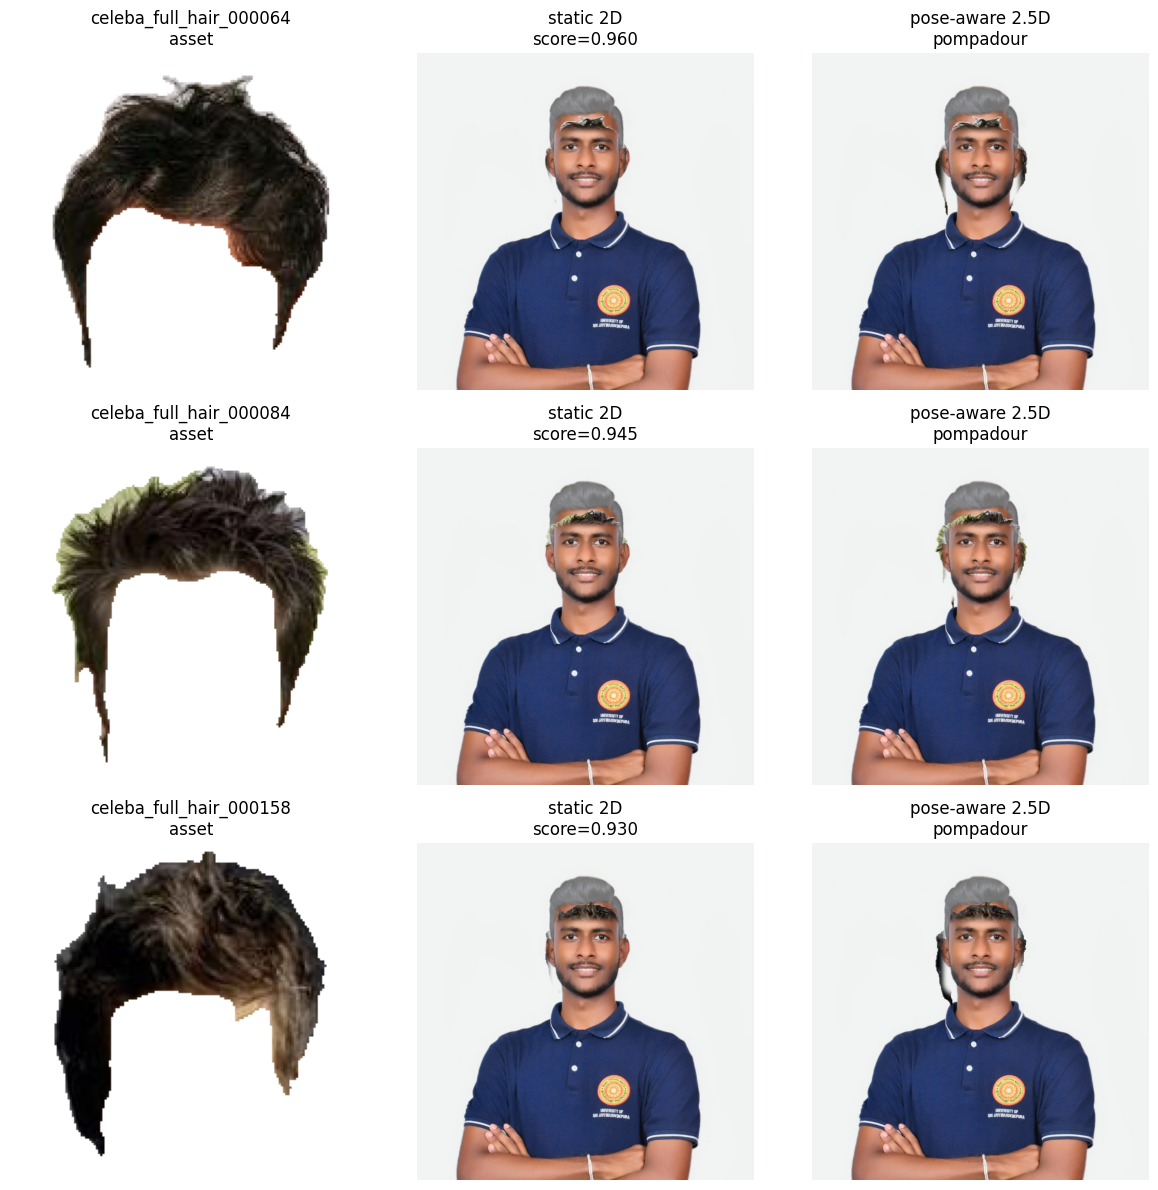

In [21]:
fig, axes = plt.subplots(len(recommendations), 3, figsize=(12, 4 * len(recommendations)))
if len(recommendations) == 1:
    axes = [axes]

for row_axes, item in zip(axes, recommendations):
    asset = get_asset_by_id(item.asset_id)
    static_preview = render_static_tryon_image(INPUT_IMAGE_PATH, analysis, asset, subject_hair_mask=subject_hair_mask)
    pose_preview = render_pose_aware_tryon_image(INPUT_IMAGE_PATH, analysis, asset, subject_hair_mask=subject_hair_mask)
    asset_image = Image.open(PROJECT_ROOT / asset.image_path).convert('RGBA')

    row_axes[0].imshow(asset_image)
    row_axes[0].set_title(f"{item.asset_id}\nasset")
    row_axes[1].imshow(static_preview)
    row_axes[1].set_title(f"static 2D\nscore={item.score:.3f}")
    row_axes[2].imshow(pose_preview)
    row_axes[2].set_title(f"pose-aware 2.5D\n{item.normalized_attributes.style_family}")
    for ax in row_axes:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
summary = {
    'input_image_path': str(INPUT_IMAGE_PATH),
    'target_gender': TARGET_GENDER,
    'asset_bank_summary': asset_bank_summary(),
    'head_anchor_frame': head_anchor,
    'top_recommendations': recommendation_table.to_dict(orient='records'),
    'status': 'pose_aware_25d_bridge',
}

summary_path = OUTPUT_DIR / 'lightweight_3d_tryon_summary.json'
csv_path = OUTPUT_DIR / 'lightweight_3d_tryon_candidates.csv'

summary_path.write_text(json.dumps(summary, indent=2), encoding='utf-8')
recommendation_table.to_csv(csv_path, index=False)

print('Saved summary to:', summary_path)
print('Saved candidates to:', csv_path)

Saved summary to: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\evaluations\lightweight_3d_tryon\lightweight_3d_tryon_summary.json
Saved candidates to: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\evaluations\lightweight_3d_tryon\lightweight_3d_tryon_candidates.csv
